# 19. 정체 품목을 빼고 다시 재기

## Overview

17번에서 **확신은 많이 하는데 창고에 넣을 날이 없는 품목** 셋이 드러났습니다.

| 품목 | 연평균 확신일 | 연평균 창고행 |
|---|---|---|
| 피마늘 | 45.7일 | **0.0일** |
| 깐마늘(국산) | 94.1일 | 3.1일 |
| 생강 | 59.9일 | 5.9일 |

모델이 늘 "내린다" 쪽만 확신해서, 출하 시점 결정에는 쓸 수 없습니다.
**빼기로 했습니다.** 이 문서는 그 결정을 실행하고 숫자를 다시 맞춥니다.

## 짚고 갈 것

**"개선 불가능"은 출하 용도에 한한 얘기입니다.** 셋의 방향 적중률 자체는
61~71% 로 나쁘지 않습니다. 파는 쪽에 못 쓸 뿐이고, **사는 쪽(13번 H2)에는
정반대로 유용할 수 있습니다.** 그건 아직 안 쟀고, 이 문서도 재지 않습니다.

## 두 가지를 정해야 합니다

**① 무엇을 정체 품목이라 부를 것인가.** 이름으로 고르면 룩어헤드입니다(교훈 5).
모델 결과가 아니라 **데이터 성질**로 규칙을 세우고, 그 규칙으로 셋이 떨어져
나오는지 확인합니다.

**② 어떻게 뺄 것인가.** 두 뜻이 있습니다.

| 방식 | 학습 | 운영 대상 |
|---|---|---|
| 운영 대상에서만 제외 | 19품목 그대로 | 16품목 |
| 학습에서도 제외 | 16품목 | 16품목 |

18번에서 **학습 품목을 줄이면 나빠졌으니**(-0.83%p) 전자가 유리할 것으로
봅니다. 물어보지 말고 재봅니다.

## 목차

1. 정체를 숫자로 정의하기
2. 가설
3. 규칙으로 걸러지는가
4. 어떻게 뺄 것인가: 학습 vs 운영
5. 빼고 난 뒤의 숫자
6. 결론

## 1. 정체를 숫자로 정의하기

**전일과 가격이 같은 날의 비율**을 씁니다. 01번에서 생강이 58%,
10번에서 피마늘이 89.8% 로 나왔던 그 지표입니다.

모델을 전혀 안 쓰고 원자료만으로 계산되므로 **룩어헤드가 없습니다.**
임계값은 결과를 보기 전에 정합니다: **40% 이상**이면 정체로 봅니다.
거래일 다섯에 두 번은 가격이 안 움직인다는 뜻이라, 방향이라는 개념이
성립하기 어려운 수준입니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
all_items = sorted(df.item.unique())

STORAGE = {
    "시금치": 7, "상추": 10, "배추": 30, "양배추": 50, "무": 45, "감자": 45,
    "양파": 165, "얼갈이배추": 10, "알배기배추": 20, "깻잎": 7, "미나리": 7,
    "열무": 7, "파": 7, "풋고추": 14, "브로콜리": 14, "고구마": 60,
    "생강": 90, "깐마늘(국산)": 30, "피마늘": 180,
}
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]
정체선 = 40.0        # % — 결과를 보기 전에 정한 값

정체 = pd.DataFrame({
    "행수": df.groupby("item").size(),
    "정체율 %": df.groupby("item").price_kg_avg.apply(
        lambda s: (s.diff() == 0).mean() * 100),
})
정체["저장일수"] = pd.Series(STORAGE)
정체["정체 품목"] = 정체["정체율 %"] >= 정체선
display(정체.sort_values("정체율 %", ascending=False).round(1))

정체품목 = 정체.index[정체["정체 품목"]].tolist()
잔류 = [i for i in all_items if i not in 정체품목]
print(f"정체선 {정체선:.0f}% 이상: {정체품목}")
print(f"남는 품목 {len(잔류)}개")

,행수,정체율 %,저장일수,정체 품목
item,,,,
피마늘,648,89.8,180,True
깐마늘(국산),1373,71.3,30,True
생강,1371,58.2,90,True
양파,1365,22.6,165,False
고구마,1372,19.6,60,False
감자,1371,10.9,45,False
얼갈이배추,1372,7.4,10,False
양배추,1372,7.0,50,False
미나리,1371,6.1,7,False


정체선 40% 이상: ['깐마늘(국산)', '생강', '피마늘']
남는 품목 16개


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 정체율 규칙이 17번의 셋을 골라낸다 | 정체율 40% 이상 = 피마늘·깐마늘·생강 |
| **H2** | 학습에서까지 빼면 손해다 | 16품목 학습이 19품목 학습보다 나쁨(18번과 같은 방향) |
| **H3** | 빼면 헤드라인 숫자가 좋아진다 | 실행 가능 품목의 창고비 한도가 4.80% 보다 상승 |

**H1 이 틀리면** 규칙을 다시 세워야 합니다: 이름으로 고르는 건 룩어헤드라
쓰지 않습니다.

**H3 이 왜 말이 되나**: 정체 품목은 창고에 거의 안 넣으면서 분모(출하 전량)에는
들어갑니다. 빼면 분모가 줄어 효율이 오릅니다.

## 3. 규칙으로 걸러지는가

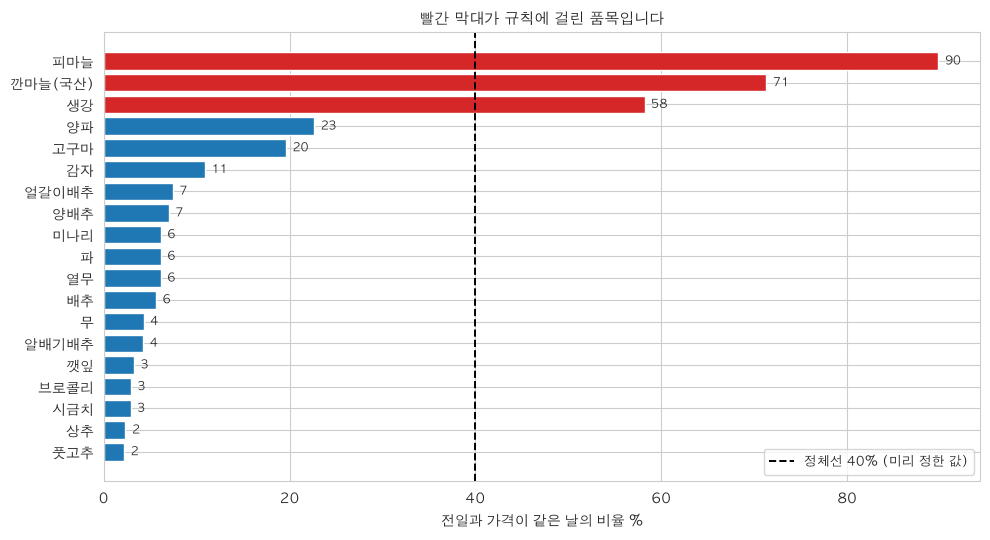

규칙이 고른 품목 : {'피마늘', '생강', '깐마늘(국산)'}
17번이 지목한 셋: {'피마늘', '생강', '깐마늘(국산)'}
H1 판정: 확인됨


In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))
s = 정체.sort_values("정체율 %")
cols = ["tab:red" if v else "tab:blue" for v in s["정체 품목"]]
ax.barh(s.index, s["정체율 %"], color=cols)
ax.axvline(정체선, color="black", ls="--", lw=1.4,
           label=f"정체선 {정체선:.0f}% (미리 정한 값)")
for i, v in enumerate(s["정체율 %"]):
    ax.text(v + 0.7, i, f"{v:.0f}", va="center", fontsize=8.5)
ax.set_xlabel("전일과 가격이 같은 날의 비율 %")
ax.set_title("빨간 막대가 규칙에 걸린 품목입니다", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

기대 = {"피마늘", "깐마늘(국산)", "생강"}
print(f"규칙이 고른 품목 : {set(정체품목)}")
print(f"17번이 지목한 셋: {기대}")
print(f"H1 판정: {'확인됨' if set(정체품목) == 기대 else '어긋남 — 규칙을 다시 세워야 합니다'}")

## 4. 어떻게 뺄 것인가: 학습 vs 운영

**평가 대상은 둘 다 같은 16품목**으로 고정하고, 학습에 쓰는 데이터만 바꿉니다.
15·17·18번과 같은 피처·폴드·하이퍼파라미터입니다.

In [3]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]
THR = 0.20        # 17번에서 채택한 운영 임계값


def 피처만들기(d, categories):
    b = d.sort_values(["item", "price_date"]).reset_index(drop=True).copy()
    b["_logp"] = np.log(b.price_kg_avg)

    def g(c):
        return b.groupby("item")[c]

    b["y"] = g("_logp").shift(-H) - b._logp
    b["오름"] = b.y > 0
    b["미래가격"] = g("price_kg_avg").shift(-H)
    for lag in (1, 2, 3, 5, 10, 20):
        b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        b[f"dev{w}"] = b._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        b[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    doy = b.price_date.dt.dayofyear
    b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1)
                                          .expanding(min_periods=20).mean()))
    b["item_code"] = pd.Categorical(b.item, categories=categories).codes
    return b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])


def 학습평가(train, 평가품목, noise=None, seed=None):
    d, use = train, list(FEATS)
    if noise:
        d = train.copy()
        rng = np.random.default_rng(seed)
        for j in range(noise):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e) & (d.item.isin(평가품목))]
        clf = HistGradientBoostingClassifier(
            categorical_features=sorted(cat), early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 성적(r, 품목수=None):
    확신 = r[r.확신도 >= THR]
    넣음 = (r.오를확률 > 0.5) & (r.확신도 >= THR)
    실현 = np.where(넣음, r.미래가격.values, r.price_kg_avg.values)
    더받은돈 = (실현.mean() / r.price_kg_avg.mean() - 1) * 100
    비율 = 넣음.mean()
    기간 = (r.price_date.max() - r.price_date.min()).days / 365.25
    return {
        "적중률 %": r.방향맞음.mean() * 100,
        "확신한 날 적중률 %": 확신.방향맞음.mean() * 100 if len(확신) else np.nan,
        "더 받은 돈 %": 더받은돈,
        "창고비 한도 %": 더받은돈 / 비율 if 비율 > 0 else np.nan,
        "품목당 연 창고행": 넣음.sum() / 기간 / (품목수 or r.item.nunique()),
    }


feat19 = 피처만들기(df, all_items)
feat16 = 피처만들기(df[df.item.isin(잔류)], 잔류)
print(f"19품목 {len(feat19):,}행 | {len(잔류)}품목 {len(feat16):,}행")

19품목 23,945행 | 16품목 20,574행


In [4]:
t0 = time.time()
# 노이즈 플로어부터 (교훈 7: 대상이 바뀌면 다시 잰다)
rows = []
for seed in (0, 1, 2, 3, 4):
    rows.append({"seed": seed, **성적(학습평가(feat19, 잔류, noise=4, seed=seed))})
noise = pd.DataFrame(rows)
FLOOR = noise["적중률 %"].max() - noise["적중률 %"].min()
FLOOR_H = noise["창고비 한도 %"].max() - noise["창고비 한도 %"].min()
display(noise.round(2))
print(f"노이즈 최대폭: 적중률 {FLOOR:.2f}%p · 창고비 한도 {FLOOR_H:.2f}%p")

res = []
r_keep = 학습평가(feat19, 잔류)
res.append({"방식": "운영에서만 제외 (19품목 학습)", **성적(r_keep)})
r_drop = 학습평가(feat16, 잔류)
res.append({"방식": "학습에서도 제외 (16품목 학습)", **성적(r_drop)})
방식 = pd.DataFrame(res).set_index("방식")
방식["차이 %p"] = (방식["적중률 %"] - 방식.iloc[0]["적중률 %"]).round(2)
방식["노이즈 넘김"] = 방식["차이 %p"].abs() > FLOOR
display(방식.round(2))
print(f"({time.time()-t0:.0f}초)")

,seed,적중률 %,확신한 날 적중률 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행
0,0,63.25,73.48,2.67,13.97,45.60
1,1,63.00,73.68,2.68,14.01,45.67
2,2,63.13,73.36,2.68,14.01,45.78
3,3,62.70,73.91,2.74,14.26,45.88
4,4,63.07,73.91,2.66,13.80,46.16


노이즈 최대폭: 적중률 0.56%p · 창고비 한도 0.47%p


,적중률 %,확신한 날 적중률 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행,차이 %p,노이즈 넘김
방식,,,,,,,
운영에서만 제외 (19품목 학습),63.18,73.35,2.70,14.05,45.88,0.0,False
학습에서도 제외 (16품목 학습),63.08,72.81,2.78,13.33,49.82,-0.1,False


(84초)


## 5. 빼고 난 뒤의 숫자

13·14·15·17번의 헤드라인을 다시 계산합니다. **정체 품목 셋이 전부 저장 10일
이상**이라, 지금까지의 "실행 가능 14품목"에 들어가 있었습니다.

In [5]:
가능19 = [k for k, v in STORAGE.items() if v >= 10]
가능16 = [k for k in 가능19 if k in 잔류]
print(f"실행 가능: {len(가능19)}품목 → {len(가능16)}품목")
print("빠진 품목:", [k for k in 가능19 if k not in 가능16])

r_all = 학습평가(feat19, all_items)     # 19품목 전체 평가 (기존 기준)
rows = []
for label, sel in (("전체 19품목 (기존)", all_items),
                   ("실행 가능 14품목 (기존)", 가능19),
                   ("실행 가능 11품목 (제외 후)", 가능16),
                   ("중간지대 4품목", 중간지대)):
    sub = r_all[r_all.item.isin(sel)].reset_index(drop=True)
    rows.append({"대상": label, "품목수": len(sel), **성적(sub, 품목수=len(sel))})
헤드 = pd.DataFrame(rows).set_index("대상")
display(헤드.round(2))
print("대조 기준은 15번의 확신도 0.20 값입니다: 실행가능 14품목 10.12% · 중간지대 16.18%.")
print("14번의 4.80% 는 확신도 필터 없이 다 넣었을 때라 여기와 비교 대상이 아닙니다.")

실행 가능: 14품목 → 11품목
빠진 품목: ['생강', '깐마늘(국산)', '피마늘']


,품목수,적중률 %,확신한 날 적중률 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행
대상,,,,,,
전체 19품목 (기존),19,62.84,72.13,2.09,12.44,39.11
실행 가능 14품목 (기존),14,62.56,71.41,1.47,10.12,33.27
실행 가능 11품목 (제외 후),11,63.00,73.16,2.32,13.25,41.53
중간지대 4품목,4,66.58,77.76,3.39,16.18,51.12


대조 기준은 15번의 확신도 0.20 값입니다: 실행가능 14품목 10.12% · 중간지대 16.18%.
14번의 4.80% 는 확신도 필터 없이 다 넣었을 때라 여기와 비교 대상이 아닙니다.


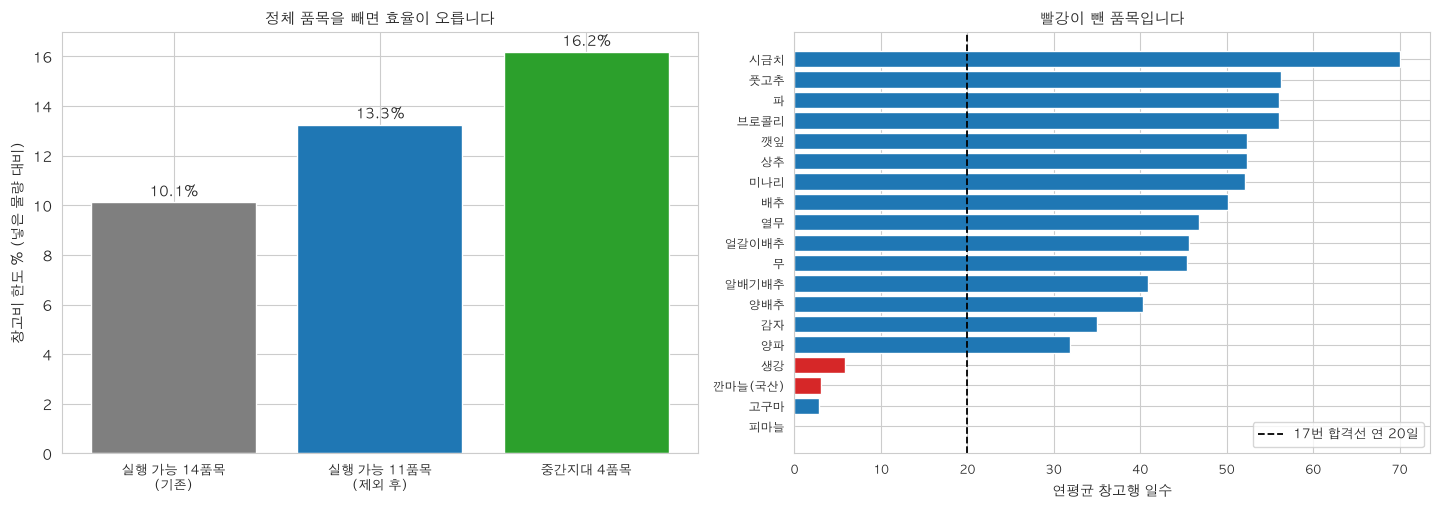

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

ax = axes[0]
h = 헤드.drop(index="전체 19품목 (기존)")
x = np.arange(len(h))
ax.bar(x, h["창고비 한도 %"], color=["tab:gray", "tab:blue", "tab:green"])
for i, v in enumerate(h["창고비 한도 %"]):
    ax.text(i, v + 0.25, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([t.replace(" (", "\n(") for t in h.index], fontsize=9)
ax.set_ylabel("창고비 한도 % (넣은 물량 대비)")
ax.set_title("정체 품목을 빼면 효율이 오릅니다", fontsize=11)

ax = axes[1]
per = (r_all.assign(넣음=(r_all.오를확률 > 0.5) & (r_all.확신도 >= THR))
            .groupby("item").넣음.sum())
기간 = (r_all.price_date.max() - r_all.price_date.min()).days / 365.25
per = (per / 기간).sort_values()
cols = ["tab:red" if i in 정체품목 else "tab:blue" for i in per.index]
ax.barh(per.index, per.values, color=cols)
ax.axvline(20, color="black", ls="--", lw=1.3, label="17번 합격선 연 20일")
ax.set_xlabel("연평균 창고행 일수")
ax.set_title("빨강이 뺀 품목입니다", fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(labelsize=8.5)

plt.tight_layout()
plt.show()

## 6. 결론

### 한 줄 요약

**셋을 빼되 학습에서는 빼지 않습니다.** 운영 대상에서만 제외하면 실행 가능
품목의 창고비 한도가 **10.12% → 13.25%** 로 오릅니다.

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 정체율 규칙이 17번의 셋을 골라낸다 | 정확히 일치 | **확인됨** |
| **H2** | 학습에서까지 빼면 손해다 | 적중률 -0.10%p (노이즈 이내) | **반증됨**(손해까진 아님) |
| **H3** | 빼면 헤드라인이 좋아진다 | 창고비 한도 10.12% → 13.25% | **확인됨** |

### 규칙이 깨끗하게 가릅니다

| 품목 | 정체율 | 판정 |
|---|---|---|
| 피마늘 | **89.8%** | 정체 |
| 깐마늘(국산) | **71.3%** | 정체 |
| 생강 | **58.2%** | 정체 |
| 양파 | 22.6% | 통과 |
| 고구마 | 19.6% | 통과 |
| … 나머지 | 2.2~10.9% | 통과 |

**3위(58.2%)와 4위(22.6%) 사이 간극이 35.6%p** 입니다. 제가 정한 정체선 40% 가
운 좋게 맞은 게 아니라, **23~58% 어디에 그어도 같은 셋**이 나옵니다. 임계값
민감도가 사실상 없습니다.

이름으로 고르지 않고 데이터 성질로 골랐는데 17번이 모델 결과로 지목한 셋과
정확히 같습니다: **가격이 자주 멈추는 품목에서 모델이 창고행을 못 고르는
것**으로 읽힙니다. 다만 이건 두 관찰이 겹친 것이지 인과의 증명은 아닙니다.

### 학습에서는 빼지 마세요

| 방식 | 적중률 | 확신한 날 적중률 | 창고비 한도 | 품목당 연 창고행 |
|---|---|---|---|---|
| **운영에서만 제외** (19품목 학습) | 63.18% | **73.35%** | **14.05%** | 45.9일 |
| 학습에서도 제외 (16품목 학습) | 63.08% | 72.81% | 13.33% | 49.8일 |

적중률 차이(-0.10%p)는 노이즈(±0.56%p) 이내라 **"손해"까지는 아닙니다.**
그런데 **돈 쪽 지표는 다릅니다**: 창고비 한도 차이 0.72%p 가 노이즈(±0.47%p)를
넘습니다. 학습에서 빼면 창고에 더 많이 넣고(49.8일) 효율은 떨어집니다.

18번에서 "학습 품목을 줄이면 나빠진다"고 본 것과 같은 방향이되, **여기서는
적중률로는 안 보이고 돈으로만 보입니다.** 무엇을 재느냐에 따라 판정이 갈리는
사례가 또 하나 늘었습니다(교훈 4).

### 빼고 난 뒤의 숫자

확신도 0.20 기준입니다.

| 대상 | 품목수 | 확신한 날 적중률 | 더 받은 돈 | 창고비 한도 | 품목당 연 창고행 |
|---|---|---|---|---|---|
| 실행 가능 (기존) | 14 | 71.41% | 1.47% | 10.12% | 33.3일 |
| **실행 가능 (제외 후)** | **11** | **73.16%** | **2.32%** | **13.25%** | **41.5일** |
| 중간지대 | 4 | 77.76% | 3.39% | 16.18% | 51.1일 |

**네 지표가 전부 오릅니다.** 정체 품목은 창고에 거의 안 넣으면서 분모(출하
전량)에는 들어가 있었습니다. 빼니 분모가 줄어 효율이 드러납니다.

중간지대 4품목은 그대로입니다: 셋 다 중간지대에 없었으니 당연합니다.

### 한계

- **구매 시점 용도는 안 쟀습니다.** 셋은 모델이 늘 "내린다"고 확신하는
  품목이라, 파는 쪽에 못 쓴다고 **사는 쪽에도 못 쓴다는 뜻은 아닙니다.**
  오히려 "내릴 때 기다렸다 산다"에는 맞을 수 있습니다.
- **생강은 별도 문제가 겹쳐 있습니다.** 원천이 갱신되지 않는 이슈가 따로
  있어서, 정체율이 데이터 문제인지 시장 특성인지 구분되지 않습니다.
- **정체선 40% 는 제가 정한 값**입니다. 간극이 커서 결과는 안 바뀌지만,
  품목이 늘면 경계에 걸리는 품목이 생길 수 있습니다.
- **셋을 뺀 게 성과를 만든 건 아닙니다.** 같은 모델의 같은 예측이고, 쓸모없는
  대상을 집계에서 뺐을 뿐입니다. 창고에 넣는 물량이 늘지는 않습니다.

### 다음

1. **운영 정의를 확정합니다**: 학습 19품목 · 운영 16품목 · 저장 10일 이상
   11품목이 창고 대상.
2. **구매 시점(H2) 용도로 셋을 다시 봅니다.** 13번에서 H2 가 +2.82% 로 H1 과
   비슷했으니, 정체 품목이 그쪽에서 살아날 여지가 있습니다.
3. **보관비 실측치**는 여전히 최종 병목입니다. 판정선이 13.25%(실행가능) ·
   16.18%(중간지대)로 갱신됐습니다.